# Extracting CellProfiler Features from Synthetic Cell Images

This notebook shows the core `cellgenerator` workflow in three steps:

1. **Generate** a synthetic cell image with a known shape and staining pattern
2. **Extract** CellProfiler morphological features from it
3. **Inspect** the resulting feature table

> **Prerequisites**  
> Step 1 is self-contained.  
> Steps 2-3 require the `cg-cellprofiler` conda environment.  
> See the [CellProfiler setup guide](../setup/cellprofiler) for instructions.

In [1]:
import matplotlib.pyplot as plt

from cellgenerator import Image
from cellgenerator.mask import EllipseMask
from cellgenerator.stain import SpatialStain
from cellgenerator.measure import CellProfilerMeasurer, CellProfilerNotFoundError

## Step 1 - Generate a synthetic cell

A `cellgenerator` image is composed of two parts:

| Part | What it controls |
|------|------------------|
| **Mask** | The cell outline (shape) |
| **Stain** | The intensity pattern inside the cell |

Here we create an elliptical cell with a spatially varying stain.

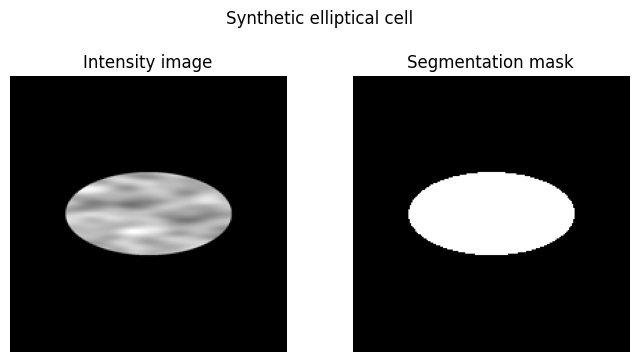

In [2]:
# Build the cell at high internal resolution; render size is set later
cell = Image(
    dim=(1000, 1000),
    mask=EllipseMask(y_radius=150, x_radius=300),
    stain=SpatialStain(y_corr=10, x_corr=40),
)

OUT = (200, 200)  # pixel size used for rendering and measurement

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
axes[0].imshow(cell.get_img(OUT), cmap="gray")
axes[0].set_title("Intensity image")
axes[0].axis("off")
axes[1].imshow(cell.get_mask_img(OUT), cmap="gray")
axes[1].set_title("Segmentation mask")
axes[1].axis("off")
fig.suptitle("Synthetic elliptical cell", y=1.02)
plt.tight_layout()
plt.show()

## Step 2 - Extract CellProfiler features

`CellProfilerMeasurer` runs CellProfiler inside its own conda environment and returns all features as a tidy `pandas.DataFrame`. Five feature groups are measured:

| Group | What it captures |
|-------|------------------|
| `AreaShape` | Size, shape, eccentricity, Zernike moments |
| `Intensity` | Mean, max, integrated intensity inside the mask |
| `Texture` | Haralick texture features at multiple length scales |
| `Granularity` | Granularity spectrum (coarse vs fine texture) |
| `RadialDistribution` | How intensity is distributed from cell centre outward |

In [3]:
try:
    measurer = CellProfilerMeasurer()
    CELLPROFILER_AVAILABLE = True
except CellProfilerNotFoundError:
    print(
        "CellProfiler environment not found.\n"
        "Steps 2-3 below will be skipped.\n"
        "To enable them, set up the cg-cellprofiler conda environment:\n"
        "  conda env create -f environment.yml"
    )
    CELLPROFILER_AVAILABLE = False

CellProfiler environment not found.
Steps 2-3 below will be skipped.
To enable them, set up the cg-cellprofiler conda environment:
  conda env create -f environment.yml


In [4]:
if CELLPROFILER_AVAILABLE:
    df = measurer.measure(cell, dim=OUT)
    print(f"Features extracted: {df.shape[1]}")

## Step 3 - Inspect the feature table

Each call to `measure()` returns a single-row `DataFrame` - one column per CellProfiler feature.

In [5]:
if CELLPROFILER_AVAILABLE:
    # One representative feature per group
    picks = [
        next((c for c in df.columns if c == "AreaShape_Area"), None),
        next((c for c in df.columns if c == "AreaShape_Eccentricity"), None),
        next((c for c in df.columns if "Intensity_MeanIntensity" in c), None),
        next((c for c in df.columns if "Intensity_IntegratedIntensity" in c), None),
        next((c for c in df.columns if c.startswith("Texture_")), None),
        next((c for c in df.columns if c.startswith("Granularity_")), None),
        next((c for c in df.columns if c.startswith("RadialDistribution_")), None),
    ]
    picks = [c for c in picks if c]
    display(df[picks].T.rename(columns={0: "value"}))

In [6]:
if CELLPROFILER_AVAILABLE:
    prefixes = ["AreaShape", "Intensity", "Texture", "Granularity", "RadialDistribution"]
    counts = {p: sum(1 for c in df.columns if c.startswith(p)) for p in prefixes}
    print("Features per group:")
    for name, n in counts.items():
        print(f"  {name:<22} {n:>4}")
    print(f"  {'TOTAL':<22} {sum(counts.values()):>4}")